In [ ]:
pip install tensorflow pandas numpy matplotlib scikit-learn pillow

In [ ]:
import pandas as pd
import numpy as np
import os

from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
import os

BASE_DIR = r"C:\Users\mehru\Downloads\AI Project"

In [46]:
csv_path = "parking.csv"
df = pd.read_csv(csv_path)
df.head()

,id,image,mask
0,0,images/0.png,boxes/0.png
1,1,images/1.png,boxes/1.png
2,2,images/2.png,boxes/2.png
3,3,images/3.png,boxes/3.png
4,4,images/4.png,boxes/4.png


In [47]:
df["image"] = df["image"].apply(lambda x: os.path.join(BASE_DIR, x))
df["mask"]  = df["mask"].apply(lambda x: os.path.join(BASE_DIR, x))

In [48]:
print(df["mask"].iloc[0])
print(os.path.exists(df["mask"].iloc[0]))

/content/drive/MyDrive/AI Project/boxes/0.png
True


In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
os.chdir("/content/drive/MyDrive/AI Project")
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/AI Project
['annotations.xml', 'parking.csv', 'boxes', 'images']


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/AI Project"
os.chdir(BASE_DIR)
os.getcwd()

'/content/drive/MyDrive/AI Project'

In [ ]:
os.listdir()

['annotations.xml', 'parking.csv', 'boxes', 'images']

In [ ]:
os.path.exists("boxes/0.png")

True

In [ ]:
import pandas as pd

df = pd.read_csv("parking.csv")
df.head()

,id,image,mask
0,0,images/0.png,boxes/0.png
1,1,images/1.png,boxes/1.png
2,2,images/2.png,boxes/2.png
3,3,images/3.png,boxes/3.png
4,4,images/4.png,boxes/4.png


In [ ]:
df = pd.read_csv("parking.csv")
df["image"] = df["image"].apply(lambda x: os.path.join(BASE_DIR, x))
df["mask"]  = df["mask"].apply(lambda x: os.path.join(BASE_DIR, x))
df

,id,image,mask
0,0,/content/drive/MyDrive/AI Project/images/0.png,/content/drive/MyDrive/AI Project/boxes/0.png
1,1,/content/drive/MyDrive/AI Project/images/1.png,/content/drive/MyDrive/AI Project/boxes/1.png
2,2,/content/drive/MyDrive/AI Project/images/2.png,/content/drive/MyDrive/AI Project/boxes/2.png
3,3,/content/drive/MyDrive/AI Project/images/3.png,/content/drive/MyDrive/AI Project/boxes/3.png
4,4,/content/drive/MyDrive/AI Project/images/4.png,/content/drive/MyDrive/AI Project/boxes/4.png
5,5,/content/drive/MyDrive/AI Project/images/5.png,/content/drive/MyDrive/AI Project/boxes/5.png
6,6,/content/drive/MyDrive/AI Project/images/6.png,/content/drive/MyDrive/AI Project/boxes/6.png
7,7,/content/drive/MyDrive/AI Project/images/7.png,/content/drive/MyDrive/AI Project/boxes/7.png
8,8,/content/drive/MyDrive/AI Project/images/8.png,/content/drive/MyDrive/AI Project/boxes/8.png
9,9,/content/drive/MyDrive/AI Project/images/9.png,/content/drive/MyDrive/AI Project/boxes/9.png


In [ ]:
from PIL import Image
import numpy as np

In [ ]:
def get_label(mask_path):
    mask = Image.open(mask_path).convert("L")
    mask = np.array(mask)
    return 1 if mask.sum() > 0 else 0

df["label"] = df["mask"].apply(get_label)
df.head()

,id,image,mask,label
0,0,/content/drive/MyDrive/AI Project/images/0.png,/content/drive/MyDrive/AI Project/boxes/0.png,1
1,1,/content/drive/MyDrive/AI Project/images/1.png,/content/drive/MyDrive/AI Project/boxes/1.png,1
2,2,/content/drive/MyDrive/AI Project/images/2.png,/content/drive/MyDrive/AI Project/boxes/2.png,1
3,3,/content/drive/MyDrive/AI Project/images/3.png,/content/drive/MyDrive/AI Project/boxes/3.png,1
4,4,/content/drive/MyDrive/AI Project/images/4.png,/content/drive/MyDrive/AI Project/boxes/4.png,1


In [ ]:
df["label"].value_counts()

,count
label,
1,30


In [ ]:
import os

missing = df[~df["mask"].apply(os.path.exists)]
print("Missing mask files:", len(missing))
missing.head()

Missing mask files: 3


,id,image,mask
7,7,/content/drive/MyDrive/AI Project/images/7.png,/content/drive/MyDrive/AI Project/boxes/7.png
16,16,/content/drive/MyDrive/AI Project/images/16.png,/content/drive/MyDrive/AI Project/boxes/16.png
23,23,/content/drive/MyDrive/AI Project/images/23.png,/content/drive/MyDrive/AI Project/boxes/23.png


In [ ]:
df = df[df["mask"].apply(os.path.exists)].reset_index(drop=True)
print("Remaining samples:", len(df))

Remaining samples: 30


In [ ]:
IMG_SIZE = (224, 224)

def load_images(image_paths):
    images = []
    for path in image_paths:
        img = load_img(path, target_size=IMG_SIZE)
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images)

X = load_images(df["image"])
y = df["label"].values

print(X.shape, y.shape)

(30, 224, 224, 3) (30,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
def build_model(base_model):
    base_model.trainable = False

    x = base_model.output
    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(base_model.input, output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
vgg_model = build_model(vgg_base)

history_vgg = vgg_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5609 - loss: 0.5096 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 1.9595e-04
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 6.6274e-04 - val_accuracy: 1.0000 - val_loss: 2.1200e-05
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 1.7725e-04 - val_accuracy: 1.0000 - val_loss: 3.8855e-06
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 1.5733e-04 - val_accuracy: 1.0000 - val_loss: 1.0435e-06
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 3.0667e-06 - val_accuracy: 1.0000 - val_loss: 3.7766e-07
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 4.8157e-06 - val_accuracy: 1.0000 - val_loss: 1.7330e-07
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 3.4957

In [ ]:
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
resnet_model = build_model(resnet_base)

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 1.0000 - loss: 0.1912 - val_accuracy: 1.0000 - val_loss: 6.7630e-07
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 4.0440e-06 - val_accuracy: 1.0000 - val_loss: 2.3002e-09
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 6.3354e-08 - val_accuracy: 1.0000 - val_loss: 5.3917e-11
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 1.0354e-09 - val_accuracy: 1.0000 - val_loss: 3.7757e-12
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 8.1668e-11 - val_accuracy: 1.0000 - val_loss: 5.3979e-13
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 1.9945e-09 - val_accuracy: 1.0000 - val_loss: 1.2703e-13
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 5.3669e-10 - val_accuracy: 1.0000 - val_loss: 4.2891e-14
Epoch 8/10
3/3 ━━━━━━━━

In [ ]:
mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
mobilenet_model = build_model(mobilenet_base)

history_mobilenet = mobilenet_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step - accuracy: 0.7072 - loss: 0.5461 - val_accuracy: 1.0000 - val_loss: 2.4438e-13
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 1.0442e-09 - val_accuracy: 1.0000 - val_loss: 1.7882e-19
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 1.5493e-12 - val_accuracy: 1.0000 - val_loss: 1.4596e-23
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 1.6079e-15 - val_accuracy: 1.0000 - val_loss: 1.8465e-26
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 3.1836e-18 - val_accuracy: 1.0000 - val_loss: 1.3971e-28
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 1.4487e-25 - val_accuracy: 1.0000 - val_loss: 3.6914e-30
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 4.0728e-19 - val_accuracy: 1.0000 - val_loss: 2.4159e-31
Epoch 8/10
3/3 ━━━━━━━━━

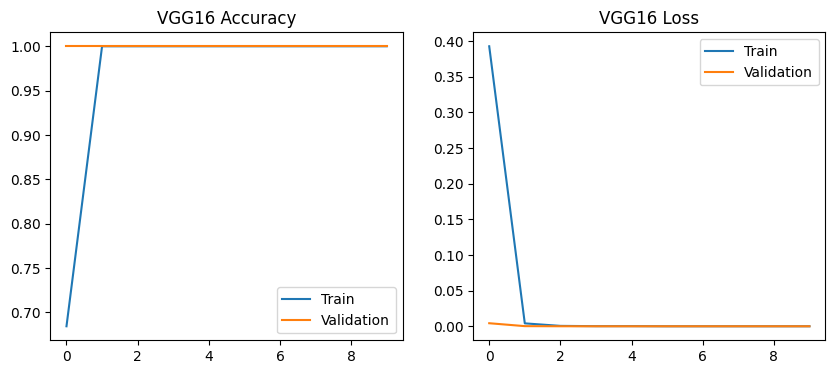

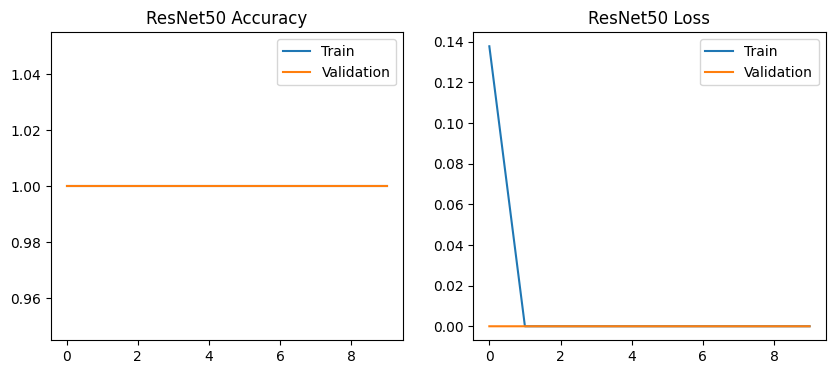

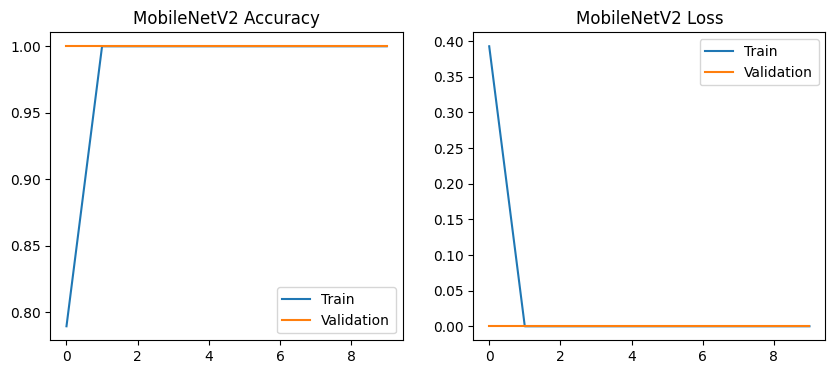

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(title + " Accuracy")
    plt.legend(["Train", "Validation"])

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(title + " Loss")
    plt.legend(["Train", "Validation"])

    plt.show()

plot_history(history_vgg, "VGG16")
plot_history(history_resnet, "ResNet50")
plot_history(history_mobilenet, "MobileNetV2")

In [ ]:
def evaluate(model, name):
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Test Accuracy: {acc*100:.2f}%")

evaluate(vgg_model, "VGG16")
evaluate(resnet_model, "ResNet50")
evaluate(mobilenet_model, "MobileNetV2")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 1.3361e-08
VGG16 Test Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 3.2050e-14
ResNet50 Test Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 4.9091e-30
MobileNetV2 Test Accuracy: 100.00%


In [ ]:
mobilenet_model.save("parking_occupancy_model.h5")

In [ ]:
def predict_image(img_path, model):
    img = load_img(img_path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    if pred[0][0] > 0.5:
        print("🚗 Occupied")
    else:
        print("🅿️ Vacant")

predict_image(df["image"].iloc[0], mobilenet_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
🚗 Occupied
